# Forecasting Produkcji PV - TSMixer vs PatchTST + SHAP & LIME

In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import shap
import sys, os
sys.path.insert(0, os.path.abspath("../"))
from model.tsmixer_wind import TSMixer, train_tsmixer, evaluate
from matplotlib.patches import Patch
import lime.lime_tabular
from collections import defaultdict


Definiujemy później wykorzystywane hiperparametry.

In [22]:
LOOKBACK   = 48   # hours of historical context
HORIZON    = 24   # hours to predict
BATCH_SIZE = 32
MAX_EPOCHS = 200
MIN_EPOCHS = 30   # never stop before this, regardless of val loss
PATIENCE   = 20  
LR         = 1e-3

Inicjalizujemy generatory liczb pseudolowoych.

In [5]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

Wybieramy urządzenie z którego będziemy korzystać w obliczeniach.

In [6]:
if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"
    
XAI_DEVICE = "cpu" 

print(f"PyTorch {torch.__version__} | Training device: {DEVICE} | XAI device: {XAI_DEVICE}")

PyTorch 2.11.0 | Training device: mps | XAI device: cpu


## 1. Data loading & feature selection

In [7]:
DATA_DIR = "../dane_merged"
train_df = pd.read_csv(f"{DATA_DIR}/dataset_train.csv", parse_dates=["Date"])
val_df   = pd.read_csv(f"{DATA_DIR}/dataset_val.csv",   parse_dates=["Date"])

In [15]:
TARGET   = "PV_MWh"
NON_FEATURE = {"Date", TARGET}
MODEL_FEATURES = sorted([c for c in train_df.columns if c not in NON_FEATURE])

# SHAP będzie się wykonywał na wszystkich cechach, wykres słupkowy pokażemy dla pierwszych SHAP_TOP_N cech
# LIME będzie używał INTERRETABLE_FEATURES
PL_FEATURES   = [c for c in MODEL_FEATURES if c.startswith("PL_")]
TIME_FEATURES = [c for c in MODEL_FEATURES if any(c.startswith(p) for p in ["hour", "day", "month", "week", "is_"])]
SOLAR_FEATURES = [c for c in MODEL_FEATURES if c.endswith("_Solar_Radiation")]
INTERPRETABLE_FEATURES = sorted(set(PL_FEATURES + TIME_FEATURES + SOLAR_FEATURES))
SHAP_TOP_N = 25

prov_feats = [c for c in MODEL_FEATURES if c not in PL_FEATURES and c not in TIME_FEATURES]
print(f"Total model features : {len(MODEL_FEATURES)}")
print(f"Province-level     : {len(prov_feats)}  (16 provinces × 9 variables)")
print(f"PL aggregates      : {len(PL_FEATURES)}")
print(f"Time           : {len(TIME_FEATURES)}")
print(f"Interpretable subset : {len(INTERPRETABLE_FEATURES)}  (used for LIME)")

Total model features : 177
Province-level     : 145  (16 provinces × 9 variables)
PL aggregates      : 18
Time           : 14
Interpretable subset : 48  (used for LIME)


In [13]:
print(f"Train rows: {len(train_df):,} \nVal rows: {len(val_df):,}")

Train rows: 10,684 
Val rows: 169


## 2. Skalowanie i sekwencje sliding-window

In [17]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_arr = scaler_X.fit_transform(train_df[MODEL_FEATURES].values.astype("float32")) # compatibility with PyTorch's default float type
y_train_arr = scaler_y.fit_transform(train_df[[TARGET]].values.astype("float32"))
X_val_arr   = scaler_X.transform(val_df[MODEL_FEATURES].values.astype("float32"))
y_val_arr   = scaler_y.transform(val_df[[TARGET]].values.astype("float32"))

def make_sequences(X, y, lookback, horizon):
    Xs, ys = [], []
    for i in range(len(X) - lookback - horizon + 1):
        Xs.append(X[i : i + lookback])
        ys.append(y[i + lookback : i + lookback + horizon, 0])
    return np.array(Xs, dtype="float32"), np.array(ys, dtype="float32")

X_train_seq, y_train_seq = make_sequences(X_train_arr, y_train_arr, LOOKBACK, HORIZON)

ctx_X = np.vstack([X_train_arr[-LOOKBACK:], X_val_arr])
ctx_y = np.vstack([y_train_arr[-LOOKBACK:], y_val_arr])
X_val_seq, y_val_seq = make_sequences(ctx_X, ctx_y, LOOKBACK, HORIZON)

ISPLIT = 500
X_nn_tr, y_nn_tr = X_train_seq[:-ISPLIT], y_train_seq[:-ISPLIT]
X_nn_vl, y_nn_vl = X_train_seq[-ISPLIT:], y_train_seq[-ISPLIT:]

def make_loader(X, y, shuffle=False):
    ds = TensorDataset(torch.FloatTensor(X), torch.FloatTensor(y))
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle)

loader_tr  = make_loader(X_nn_tr, y_nn_tr, shuffle=True)
loader_vl  = make_loader(X_nn_vl, y_nn_vl)
loader_val = make_loader(X_val_seq, y_val_seq)

features_nmbr = X_train_seq.shape[2]
n_seq      = len(X_val_seq)
print(f"X_train : {X_train_seq.shape}  y_train : {y_train_seq.shape}")
print(f"X_val   : {X_val_seq.shape}  y_val   : {y_val_seq.shape}")
print(f"features_nmbr = {features_nmbr}")

X_train : (10613, 48, 177)  y_train : (10613, 24)
X_val   : (146, 48, 177)  y_val   : (146, 24)
features_nmbr = 177


In [18]:
def train_model(model, train_loader, val_loader,
                epochs=100, min_epochs=30, lr=1e-3,
                weight_decay=1e-4, patience=20, device=DEVICE):
    model = model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    # Cosine annealing: LR smoothly decays from lr -> 0 over T_max epochs
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=lr * 0.01)
    criterion = nn.MSELoss()

    best_val, best_state, patience_counter = float('inf'), None, 0
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_b), y_b)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for X_b, y_b in val_loader:
                val_losses.append(criterion(model(X_b.to(device)), y_b.to(device)).item())

        tl, vl = float(np.mean(train_losses)), float(np.mean(val_losses))
        history['train_loss'].append(tl)
        history['val_loss'].append(vl)
        scheduler.step()

        if epoch % 10 == 0 or epoch == 1:
            print(f'Epoch {epoch:4d} | train={tl:.4f}  val={vl:.4f}'
                  f'  lr={optimizer.param_groups[0]["lr"]:.2e}')

        if vl < best_val - 1e-4:
            best_val = vl
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        elif epoch >= min_epochs:   # patience only active after min_epochs
            patience_counter += 1
            if patience_counter >= patience:
                print(f'Early stopping at epoch {epoch}. Best val: {best_val:.4f}')
                break

    if best_state:
        model.load_state_dict(best_state)
    return history

## 3. Model 1 - TSMixer
TSMixer: An All-MLP Architecture for Time Series Forecasting - https://arxiv.org/abs/2303.06053

In [19]:
tsmixer = TSMixer(
    seq_len    = LOOKBACK,
    horizon    = HORIZON,
    n_features = features_nmbr,
    n_blocks   = 2,
    expansion  = 2,
    dropout    = 0.2,
).to(DEVICE)

n_params_ts = sum(p.numel() for p in tsmixer.parameters() if p.requires_grad)
print(f"TSMixer trainable parameters: {n_params_ts:,}")

TSMixer trainable parameters: 461,742


In [23]:
print("Training TSMixer...")
history_ts = train_model(
    tsmixer, loader_tr, loader_vl,
    epochs=MAX_EPOCHS, min_epochs=MIN_EPOCHS,
    lr=LR, weight_decay=1e-4,
    patience=PATIENCE, device=DEVICE,
)

Training TSMixer...
Epoch    1 | train=0.2005  val=0.3224  lr=1.00e-03
Epoch   10 | train=0.0580  val=0.3917  lr=9.94e-04
Epoch   20 | train=0.1117  val=0.3273  lr=9.76e-04
Epoch   30 | train=0.1256  val=0.3375  lr=9.46e-04
Epoch   40 | train=0.0815  val=0.3787  lr=9.05e-04
Early stopping at epoch 49. Best val: 0.2239



───────────────────────────────────
  MAE  : 1355.4441
  RMSE : 1834.3517
  MAPE : 330.24%
───────────────────────────────────



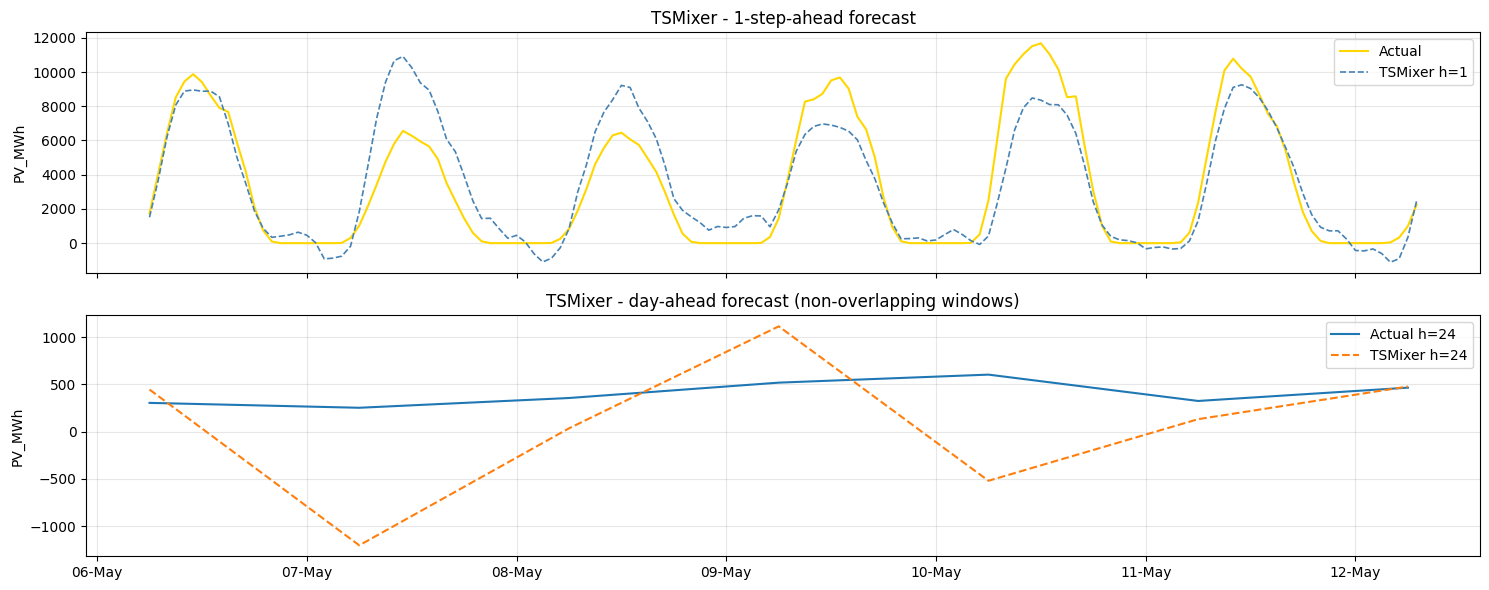

In [26]:
preds_ts, trues_ts, metrics_ts = evaluate(tsmixer, loader_val, scaler_y=scaler_y, device=DEVICE)

plot_dates = val_df["Date"].values[:n_seq]

fig, axes = plt.subplots(2, 1, figsize=(15, 6), sharex=True)
axes[0].plot(plot_dates, trues_ts[:, 0], color="gold",     lw=1.5, label="Actual")
axes[0].plot(plot_dates, preds_ts[:, 0], color="steelblue", lw=1.2, ls="--", label="TSMixer h=1")
axes[0].set_title("TSMixer - 1-step-ahead forecast")
axes[0].set_ylabel("PV_MWh")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(plot_dates[::HORIZON], trues_ts[::HORIZON, -1], label="Actual h=24")
axes[1].plot(plot_dates[::HORIZON], preds_ts[::HORIZON, -1], ls="--", label="TSMixer h=24")
axes[1].set_title("TSMixer - day-ahead forecast (non-overlapping windows)")
axes[1].set_ylabel("PV_MWh")
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
plt.tight_layout(); plt.show()

Na górnym wykresie przedstawiono predykcję krótkoterminową (z godzinnym wyprzedzeniem, h=1). Model wykazuje się tutaj wysoką precyzją, bezbłędnie wychwytując kluczowe punkty zwrotne, takie jak nagły spadek produkcji na początku nocy czy jej wzrost o poranku. Zmiany trajektorii trendu pokrywają się w czasie z danymi rzeczywistymi.

Z kolei predykcje z drugiego wykresu (dzień w przód, h=24) stanowią prawdziwy sprawdzian kompetencji modelu. Prognozowanie z tak dużym wyprzedzeniem, bez możliwości bieżącej korekty, generuje znaczne rozbieżności w stosunku do realnej produkcji PV, co odzwierciedla wysoki błąd MAPE (wynoszący ok. 300%).

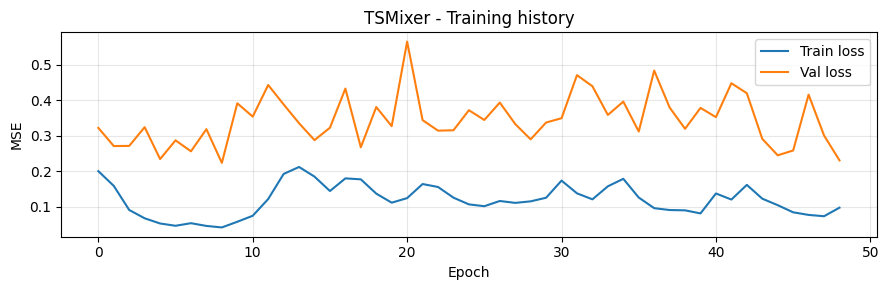

In [28]:
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(history_ts["train_loss"], label="Train loss")
ax.plot(history_ts["val_loss"],   label="Val loss")
ax.set_title("TSMixer - Training history")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE")
ax.legend() 
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3. Model 2 - PatchTST
https://arxiv.org/abs/2211.14730

In [29]:
class PatchEmbedding(nn.Module):
    # Linear projection of each (patch_len x n_features) patch into d_model space
    def __init__(self, n_features, patch_len, d_model, dropout=0.1):
        super().__init__()
        self.patch_len = patch_len
        self.proj      = nn.Linear(patch_len * n_features, d_model)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, x):
        # x: (B, T, F)
        B, T, F = x.shape
        n_patches = T // self.patch_len
        x = x[:, : n_patches * self.patch_len, :]
        x = x.reshape(B, n_patches, self.patch_len * F)
        return self.dropout(self.proj(x))   # (B, n_patches, d_model)


class PatchTST(nn.Module):
    # Channel-mixing PatchTST: multivariate -> univariate forecasting
    def __init__(self, seq_len, horizon, n_features,
                 patch_len=8, d_model=64, n_heads=4, n_layers=2, dropout=0.1):
        super().__init__()
        assert seq_len % patch_len == 0
        self.n_patches   = seq_len // patch_len
        self.patch_embed = PatchEmbedding(n_features, patch_len, d_model, dropout)

        # Learnable positional embeddings (one per patch token)
        self.pos_embed = nn.Parameter(torch.zeros(1, self.n_patches, d_model))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=d_model * 4, dropout=dropout,
            batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(self.n_patches * d_model, horizon)

    def forward(self, x):
        x = self.patch_embed(x)       # (B, n_patches, d_model)
        x = x + self.pos_embed
        x = self.transformer(x)
        x = self.norm(x)
        return self.head(x.flatten(1))  # (B, horizon)

In [32]:
patchtst = PatchTST(
    seq_len    = LOOKBACK,   # 48
    horizon    = HORIZON,    # 24
    n_features = features_nmbr,
    patch_len  = 8,          # 48 / 8 = 6 patch tokens
    d_model    = 64,
    n_heads    = 4,
    n_layers   = 2,
    dropout    = 0.1,
).to(DEVICE)

n_params_pt = sum(p.numel() for p in patchtst.parameters() if p.requires_grad)
print(f"PatchTST trainable parameters: {n_params_pt:,}")

PatchTST trainable parameters: 200,408


Model jest dwukrotnie mniejszy w porównaniu do tsmixera.

In [33]:
print("Training PatchTST...")
history_pt = train_model(
    patchtst, loader_tr, loader_vl,
    epochs=MAX_EPOCHS, min_epochs=MIN_EPOCHS,
    lr=LR, weight_decay=1e-4,
    patience=PATIENCE, device=DEVICE,
)

Training PatchTST...
Epoch    1 | train=0.1237  val=0.1981  lr=1.00e-03
Epoch   10 | train=0.0210  val=0.3536  lr=9.94e-04
Epoch   20 | train=0.0144  val=0.2804  lr=9.76e-04
Epoch   30 | train=0.0119  val=0.3636  lr=9.46e-04
Epoch   40 | train=0.0100  val=0.3226  lr=9.05e-04
Early stopping at epoch 49. Best val: 0.1937



───────────────────────────────────
  MAE  : 776.1799
  RMSE : 1246.7411
  MAPE : 85.58%
───────────────────────────────────



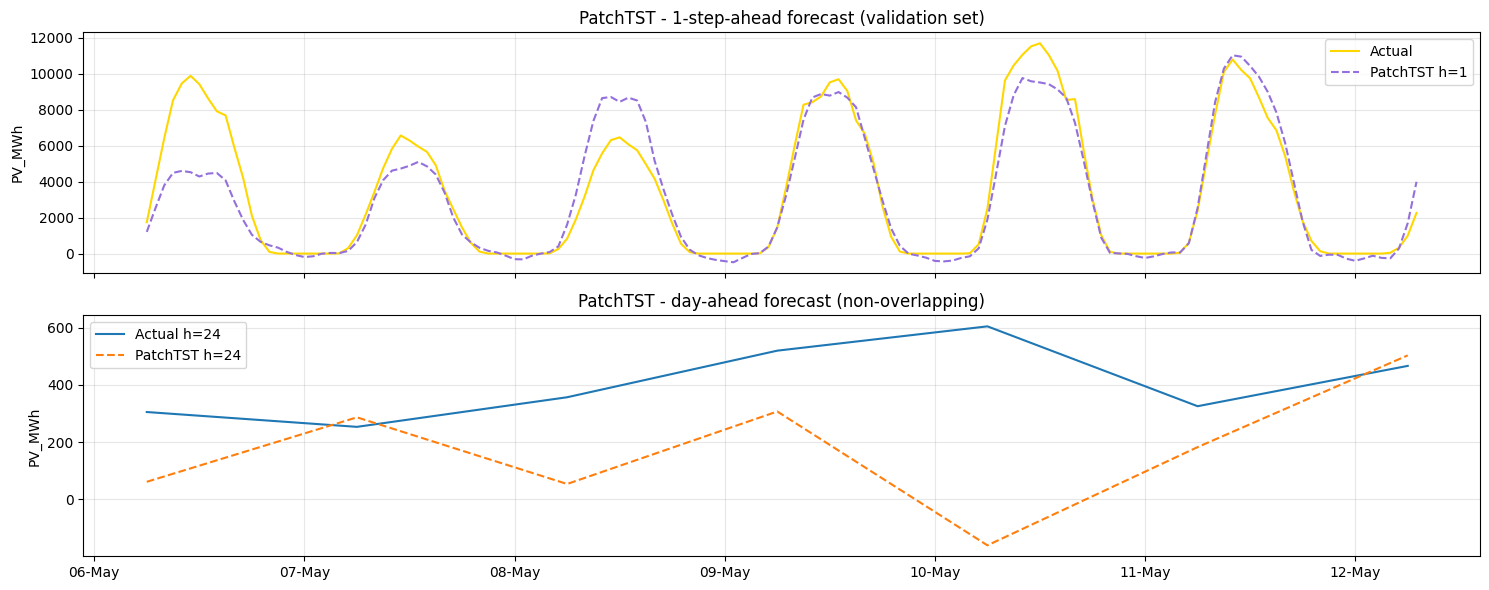

In [34]:
preds_pt, trues_pt, metrics_pt = evaluate(patchtst, loader_val, scaler_y=scaler_y, device=DEVICE)

fig, axes = plt.subplots(2, 1, figsize=(15, 6), sharex=True)
axes[0].plot(plot_dates, trues_pt[:, 0], color="gold", label="Actual")
axes[0].plot(plot_dates, preds_pt[:, 0], color="mediumpurple", ls="--", label="PatchTST h=1")
axes[0].set_title("PatchTST - 1-step-ahead forecast (validation set)")
axes[0].set_ylabel("PV_MWh")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(plot_dates[::HORIZON], trues_pt[::HORIZON, -1], label="Actual h=24")
axes[1].plot(plot_dates[::HORIZON], preds_pt[::HORIZON, -1], ls="--", label="PatchTST h=24")
axes[1].set_title("PatchTST - day-ahead forecast (non-overlapping)")
axes[1].set_ylabel("PV_MWh")
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
plt.tight_layout(); plt.show()

Architektura PatchTST oparta na tranformerze uzyskuje znacznie lepsze wyniki w prognozowaniu produkcji PV w porównaniu do modelu TSMixer (MLP). Wskaźnik błędu MAPE dla PatchTST wynosi poniżej 90% (tsmixer - ok. 400%).
Analiza wizualna wykresów potwierdza te metryki – linia predykcji PatchTST odzwierciedla realną produkcję z dużo większą dokładnością, lepiej radząc sobie z trendem w długim horyzoncie czasowym (h=24).

Dodatkowo należy pamiętać, że metryka jak MAPE zawsze będzie wysoką metryką, szczególnie ze względu na porównania do rzeczywistych wartości produkcji pv w porach nocnych, kiedy wynosi ona ok 0 MWh.

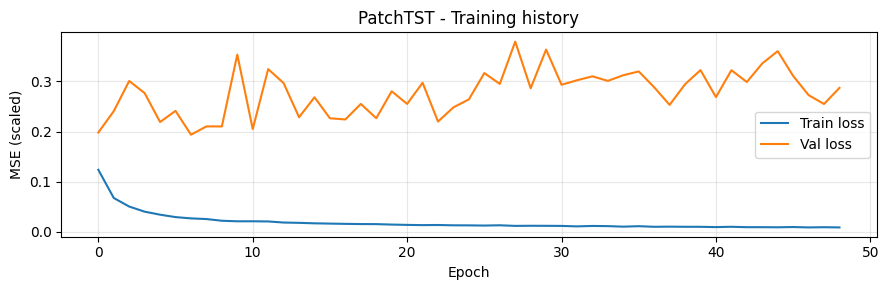

In [35]:
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(history_pt["train_loss"], label="Train loss")
ax.plot(history_pt["val_loss"],   label="Val loss")
ax.set_title("PatchTST - Training history")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE (scaled)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4. Selecting best model

In [36]:
NIGHT_THRESH = 50   # MWh: hours below this are treated as 'night' for daytime metrics

def compute_metrics(y_true, y_pred, name='Model', naive_mae=None, seasonal_naive_mae=None):
    y_true, y_pred = y_true.flatten(), y_pred.flatten()
    mae  = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    smape = np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred) + 1e-6)) * 100

    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    r2 = 1 - ss_res / (ss_tot + 1e-9)

    mask = y_true > NIGHT_THRESH
    mae_day  = np.mean(np.abs(y_true[mask] - y_pred[mask])) if mask.sum() > 0 else np.nan
    mape_day = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if mask.sum() > 0 else np.nan
    r2_day   = (1 - np.sum((y_true[mask]-y_pred[mask])**2) / (np.sum((y_true[mask]-y_true[mask].mean())**2)+1e-9))\
               if mask.sum() > 1 else np.nan

    skill = (1 - mae / naive_mae) if naive_mae else np.nan

    mase  = (mae / seasonal_naive_mae) if seasonal_naive_mae else np.nan

    n_days = len(y_true) // HORIZON
    if n_days > 0:
        y24  = y_true[:n_days*HORIZON].reshape(n_days, HORIZON).sum(axis=1)
        p24  = y_pred[:n_days*HORIZON].reshape(n_days, HORIZON).sum(axis=1)
        daily_err = np.mean(np.abs(y24 - p24) / (y24 + 1e-6)) * 100
    else:
        daily_err = np.nan

    return {
        'Model':         name,
        'MAE':           round(mae, 1),
        'RMSE':          round(rmse, 1),
        'sMAPE (%)':     round(smape, 1),
        'R2':            round(r2, 4),
        'Skill Score':   round(skill, 4) if not np.isnan(skill) else 'N/A',
        'MASE':          round(mase, 4)  if not np.isnan(mase)  else 'N/A',
        'MAE daytime':   round(mae_day, 1),
        'MAPE day (%)':  round(mape_day, 1),
        'R2 daytime':    round(r2_day, 4),
        'Daily err (%)': round(daily_err, 1),
    }

In [37]:
persist_preds = np.zeros_like(trues_ts)
for k in range(len(trues_ts)):
    last_known = scaler_y.inverse_transform([[ctx_y[k + LOOKBACK - 1, 0]]])[0, 0]
    persist_preds[k] = last_known

persist_mae = np.mean(np.abs(trues_ts.flatten() - persist_preds.flatten()))

SEASON_LAG = 7 * 24
if LOOKBACK >= SEASON_LAG:
    sn_preds = np.zeros_like(trues_ts)
    ctx_y_inv = scaler_y.inverse_transform(ctx_y)[:, 0]
    for k in range(len(trues_ts)):
        for h in range(HORIZON):
            hist_idx = k + LOOKBACK + h - SEASON_LAG
            sn_preds[k, h] = ctx_y_inv[hist_idx] if hist_idx >= 0 else 0.0
    sn_mae = np.mean(np.abs(trues_ts.flatten() - sn_preds.flatten()))
else:
    sn_mae = persist_mae

print(f'Baseline: persistence MAE       = {persist_mae:.1f} MWh')
print(f'Baseline: seasonal naive MAE    = {sn_mae:.1f} MWh  (same hour, 7 days ago)')


Baseline: persistence MAE       = 3863.2 MWh
Baseline: seasonal naive MAE    = 3863.2 MWh  (same hour, 7 days ago)


In [38]:
rows = []
for model_name, preds_arr in [
    ('Persistence',    persist_preds),
    ('TSMixer',        preds_ts),
    ('PatchTST',       preds_pt),
]:
    rows.append(compute_metrics(
        trues_ts, preds_arr,
        name              = model_name,
        naive_mae         = persist_mae,
        seasonal_naive_mae = sn_mae,
    ))

metrics_df = pd.DataFrame(rows)
metrics_df

,Model,MAE,RMSE,sMAPE (%),R2,Skill Score,MASE,MAE daytime,MAPE day (%),R2 daytime,Daily err (%)
0,Persistence,3863.199951,5079.000000,151.000000,-0.9663,0.0000,1.0000,4114.299805,356.000000,-1.2416,100.300003
1,TSMixer,1355.400024,1834.400024,99.199997,0.7435,0.6491,0.3509,1703.099976,79.400002,0.5972,28.600000
2,PatchTST,776.200012,1246.699951,89.199997,0.8815,0.7991,0.2009,1078.199951,39.200001,0.8025,18.900000


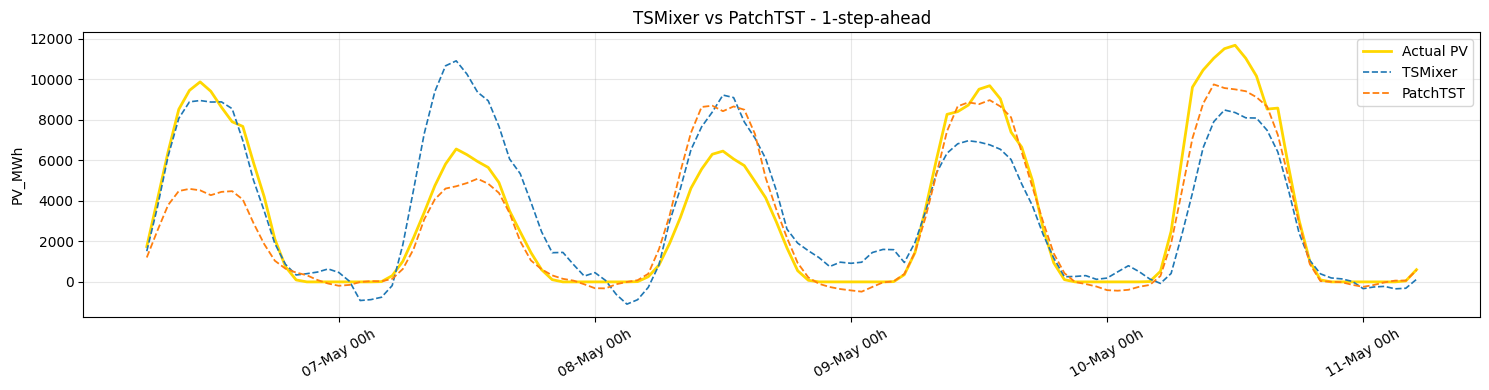

In [44]:
N_PLOT = min(5 * 24, n_seq)
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(plot_dates[:N_PLOT], trues_ts[:N_PLOT, 0], color="gold", lw=2.0, label="Actual PV")
ax.plot(plot_dates[:N_PLOT], preds_ts[:N_PLOT, 0], lw=1.2, ls="--", label="TSMixer")
ax.plot(plot_dates[:N_PLOT], preds_pt[:N_PLOT, 0], lw=1.3, ls="--", label="PatchTST")
ax.set_title("TSMixer vs PatchTST - 1-step-ahead")
ax.set_ylabel("PV_MWh")
ax.legend()
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b %Hh"))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [45]:
best_model, best_name = (tsmixer, 'TSMixer') if float(metrics_df.loc[metrics_df['Model']=='TSMixer','MAE'].values[0]) <= float(metrics_df.loc[metrics_df['Model']=='PatchTST','MAE'].values[0]) else (patchtst, 'PatchTST')
print(f'\nBest model: {best_name}')


Best model: PatchTST


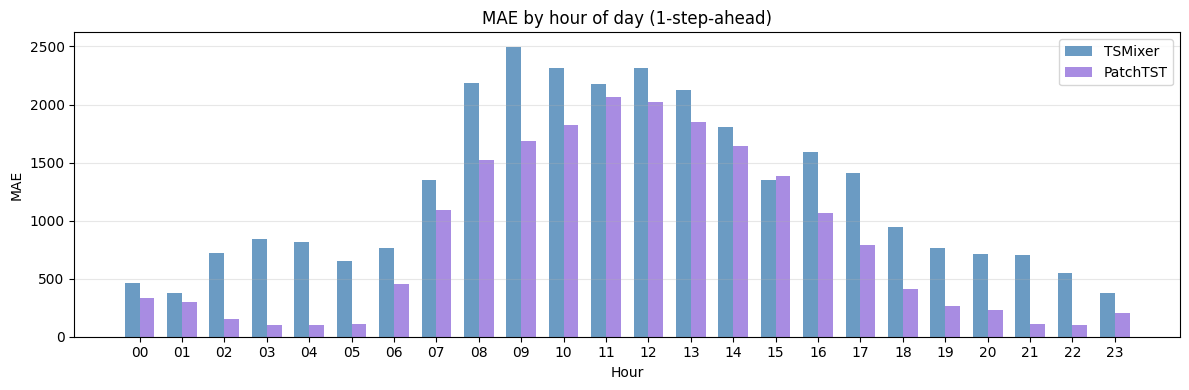

In [46]:
def hourly_mae(trues, preds, val_df, n_seq):
    actual_hours = val_df["hour"].values[:n_seq]
    return {h: np.mean(np.abs(trues[actual_hours == h, 0] - preds[actual_hours == h, 0]))
            for h in range(24) if (actual_hours == h).sum() > 0}

mae_h_ts = hourly_mae(trues_ts, preds_ts, val_df, n_seq)
mae_h_pt = hourly_mae(trues_pt, preds_pt, val_df, n_seq)
hours = sorted(mae_h_ts.keys())
x = np.arange(len(hours)); w = 0.35

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x - w/2, [mae_h_ts[h] for h in hours], w, color="steelblue",    alpha=0.8, label="TSMixer")
ax.bar(x + w/2, [mae_h_pt[h] for h in hours], w, color="mediumpurple", alpha=0.8, label="PatchTST")
ax.set_xticks(x); ax.set_xticklabels([f"{h:02d}" for h in hours])
ax.set_title("MAE by hour of day (1-step-ahead)")
ax.set_xlabel("Hour")
ax.set_ylabel("MAE")
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## 5. Ważność cech -- SHAP

In [48]:
class ScalarWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        return self.model(x).sum(dim=1, keepdim=True)   # (B, 1)

best_model.eval()
scalar_model = ScalarWrapper(best_model).to(XAI_DEVICE)

rng    = np.random.default_rng(SEED)
bg_idx = rng.choice(len(X_nn_tr), 150, replace=False)
background = torch.FloatTensor(X_nn_tr[bg_idx]).to(XAI_DEVICE)

test_seqs = torch.FloatTensor(X_val_seq[:60]).to(XAI_DEVICE)

print(f"Computing SHAP values (GradientExplainer on {XAI_DEVICE}) ...")
shap_explainer = shap.GradientExplainer(scalar_model, background)
shap_raw = shap_explainer.shap_values(test_seqs)
shap_vals = np.array(shap_raw[0]) if isinstance(shap_raw, list) else np.array(shap_raw)
if shap_vals.ndim == 4 and shap_vals.shape[-1] == 1:
    shap_vals = shap_vals.squeeze(-1)   # (n, LOOKBACK, N_FEATURES)
print(f"SHAP values shape: {shap_vals.shape}  (expected: (60, {LOOKBACK}, {N_FEATURES}))")

Computing SHAP values (GradientExplainer on cpu) ...
SHAP values shape: (60, 48, 177)  (expected: (60, 48, 177))


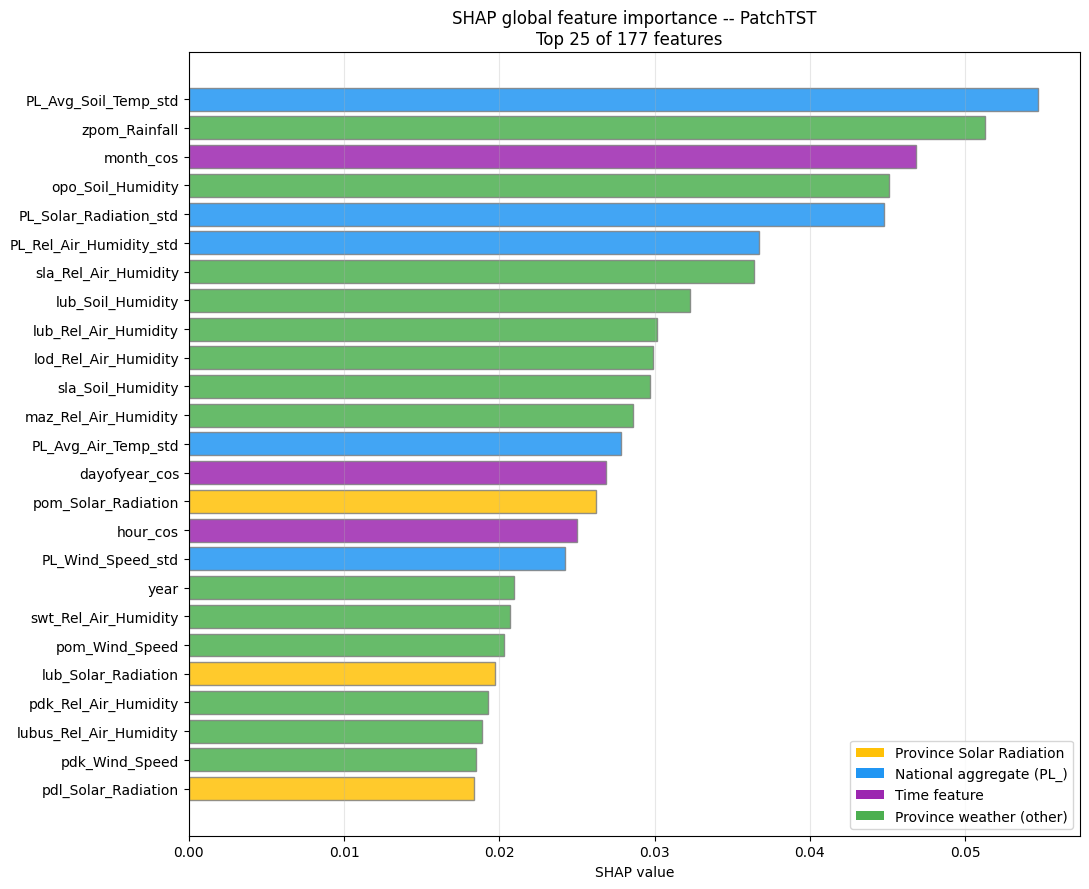

In [53]:
feat_importance = np.abs(shap_vals).mean(axis=(0, 1))
feat_imp_df = (
    pd.DataFrame({"feature": MODEL_FEATURES, "shap_importance": feat_importance})
    .sort_values("shap_importance", ascending=False)
    .reset_index(drop=True)
)

top_df = feat_imp_df.head(SHAP_TOP_N)

def feat_color(name):
    if name.startswith("PL_"):                    return "#2196F3"  # national aggregate
    if "_Solar_Radiation" in name:                return "#FFC107"  # solar radiation
    if any(name.startswith(p) for p in ["hour","day","month","week","is_"]): return "#9C27B0"  # time
    return "#4CAF50"   # other province weather

colors = [feat_color(f) for f in top_df["feature"]]

fig, ax = plt.subplots(figsize=(11, 9))
ax.barh(top_df["feature"][::-1], top_df["shap_importance"][::-1],
        color=colors[::-1], edgecolor="gray", alpha=0.85)
ax.set_title(f"SHAP global feature importance -- {best_name}\nTop {SHAP_TOP_N} of {len(MODEL_FEATURES)} features  ",)
ax.set_xlabel("SHAP value")
ax.grid(alpha=0.3, axis="x")

legend_elements = [
    Patch(facecolor="#FFC107", label="Province Solar Radiation"),
    Patch(facecolor="#2196F3", label="National aggregate (PL_)"),
    Patch(facecolor="#9C27B0", label="Time feature"),
    Patch(facecolor="#4CAF50", label="Province weather (other)"),
]
ax.legend(handles=legend_elements, loc="lower right")
plt.tight_layout(); plt.show()

In [55]:
print(f"Top 15 of {len(MODEL_FEATURES)} features by SHAP importance:")
feat_imp_df.head(15)

Top 15 of 177 features by SHAP importance:


,feature,shap_importance
0,PL_Avg_Soil_Temp_std,0.054666
1,zpom_Rainfall,0.051293
2,month_cos,0.046814
3,opo_Soil_Humidity,0.045071
4,PL_Solar_Radiation_std,0.044784
5,PL_Rel_Air_Humidity_std,0.036702
6,sla_Rel_Air_Humidity,0.036423
7,lub_Soil_Humidity,0.032274
8,lub_Rel_Air_Humidity,0.030178
9,lod_Rel_Air_Humidity,0.029886


In [56]:
print(f"\nBottom 5 (least relevant features):")
feat_imp_df.tail(5)


Bottom 5 (least relevant features):


,feature,shap_importance
172,sla_Snowfall,0.001345
173,kup_Snowfall,0.001316
174,wie_Snowfall,0.001251
175,lod_Snowfall,0.001168
176,dol_Snowfall,0.001152


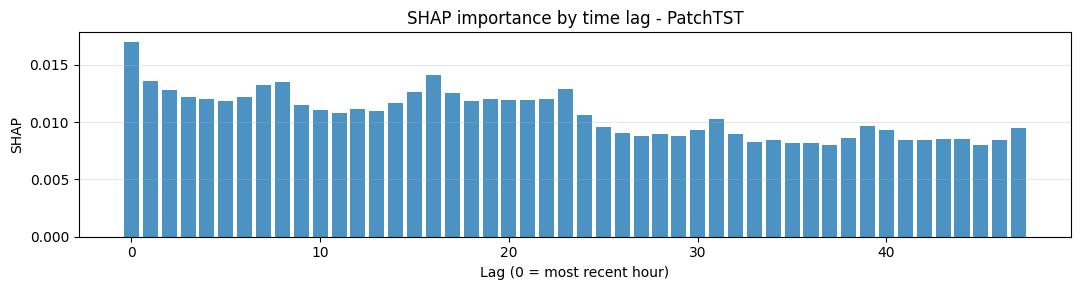

In [58]:
lag_importance = np.abs(shap_vals).mean(axis=(0, 2))

fig, ax = plt.subplots(figsize=(11, 3))
ax.bar(range(LOOKBACK), lag_importance[::-1],  alpha=0.8)
ax.set_xlabel("Lag (0 = most recent hour)")
ax.set_ylabel("SHAP")
ax.set_title(f"SHAP importance by time lag - {best_name}")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

W przypadku prognozy krótkoterminowej (na następną godzinę) kluczowe znaczenie dla modelu ma stan zmiennych z bezpośrednio poprzedzającego momentu, czyli Lag 0 (najświeższa dostępna godzina). Wartości położone głębiej w przeszłości (Lag 1 i starsze) nie wyróżniają się już tak silnym, jednostkowym wpływem, ale raczej analiza wykresu potwierdza, że model efektywnie agreguje informacje z pełnego, 48-godzinnego okna historycznego.

Świadczy to o tym, że architektura nie opiera się wyłącznie na mechanizmie naiwnej ekstrapolacji ostatniego punktu, lecz wykorzystuje dłuższą historię do identyfikacji szerszego kontekstu meteorologicznego oraz dobowej cykliczności produkcji energii.

/var/folders/mg/dphd82dn4z53n1pwgpjmb8600000gn/T/ipykernel_46686/1938947168.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


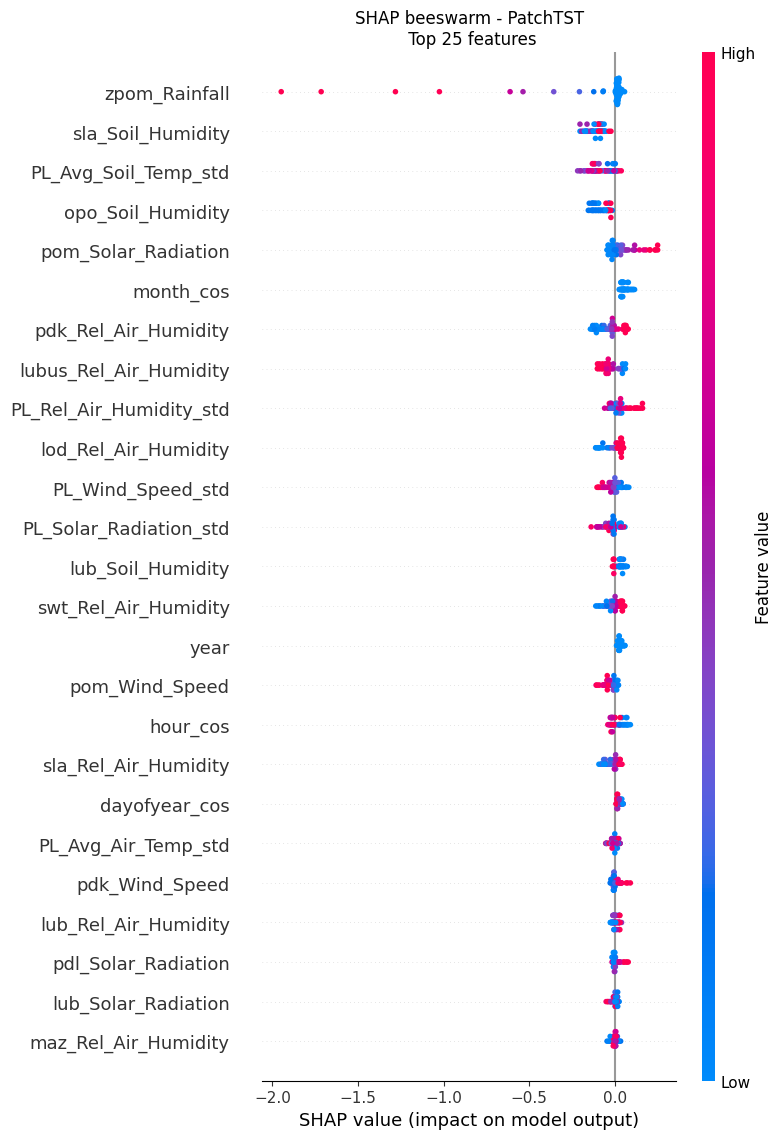

In [60]:
top_feat_names = feat_imp_df["feature"].head(SHAP_TOP_N).tolist()
top_feat_idx   = [MODEL_FEATURES.index(f) for f in top_feat_names]

shap_top = shap_vals[:, -1, top_feat_idx]          # (n_samples, SHAP_TOP_N)
X_top_bg = X_val_seq[:shap_vals.shape[0], -1, :][:, top_feat_idx]

shap.summary_plot(
    shap_top,
    features      = X_top_bg,
    feature_names = top_feat_names,
    max_display   = SHAP_TOP_N,
    plot_type     = "dot",
    show          = False,
)
plt.title(
    f"SHAP beeswarm - {best_name}\n Top {SHAP_TOP_N} features",
)
plt.tight_layout()
plt.show()

## 5. Ważność cechy - LIME

In [64]:
fixed_ctx = X_train_arr[-(LOOKBACK - 1):]   # (47, N_FEATURES)

interp_idx      = [MODEL_FEATURES.index(f) for f in INTERPRETABLE_FEATURES if f in MODEL_FEATURES]
INTERP_FEAT_NAMES = [MODEL_FEATURES[i] for i in interp_idx]
n_interp = len(interp_idx)

def predict_for_lime(X_2d):
    full_X = np.zeros((len(X_2d), features_nmbr), dtype="float32")
    full_X[:, interp_idx] = X_2d.astype("float32")
    seqs = np.tile(fixed_ctx[np.newaxis], (len(X_2d), 1, 1)).copy()
    seqs = np.concatenate([seqs, full_X[:, np.newaxis, :]], axis=1)
    with torch.no_grad():
        out = best_model(torch.FloatTensor(seqs).to(XAI_DEVICE)).cpu().numpy()
    return out.sum(axis=1)

lime_train_bg = X_train_arr[:, interp_idx]
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data = lime_train_bg,
    feature_names = INTERP_FEAT_NAMES,
    mode          = "regression",
    random_state  = SEED,
)
print(f"LIME explainer ready with {n_interp} interpretable features.")

LIME explainer ready with 48 interpretable features.


In [65]:
pv_vals = val_df[TARGET].values
hours_v = val_df["hour"].values

peak_idx  = int(np.argmax(pv_vals))

noon_mask = (hours_v == 12) & (pv_vals > 0)
cloudy_idx = int(np.where(noon_mask)[0][np.argmin(pv_vals[noon_mask])]) if noon_mask.any() else 0

morning_mask = (hours_v >= 7) & (hours_v <= 9) & (pv_vals > 0.05 * pv_vals.max())
morning_idx  = int(morning_mask.nonzero()[0][0]) if morning_mask.any() else peak_idx

cases = [
    (peak_idx,    "Peak production",  "#FFC107"),
    (cloudy_idx,  "Cloudy noon",      "#607D8B"),
    (morning_idx, "Morning ramp-up",  "#4CAF50"),
]

print("Hours to explain:")
for idx, label, _ in cases:
    print(f"  {label:20s}  {val_df['Date'].iloc[idx]}  PV={pv_vals[idx]:.0f} MWh")

Hours to explain:
  Peak production       2026-05-10 12:00:00  PV=11682 MWh
  Cloudy noon           2026-05-07 12:00:00  PV=6282 MWh
  Morning ramp-up       2026-05-06 07:00:00  PV=4068 MWh


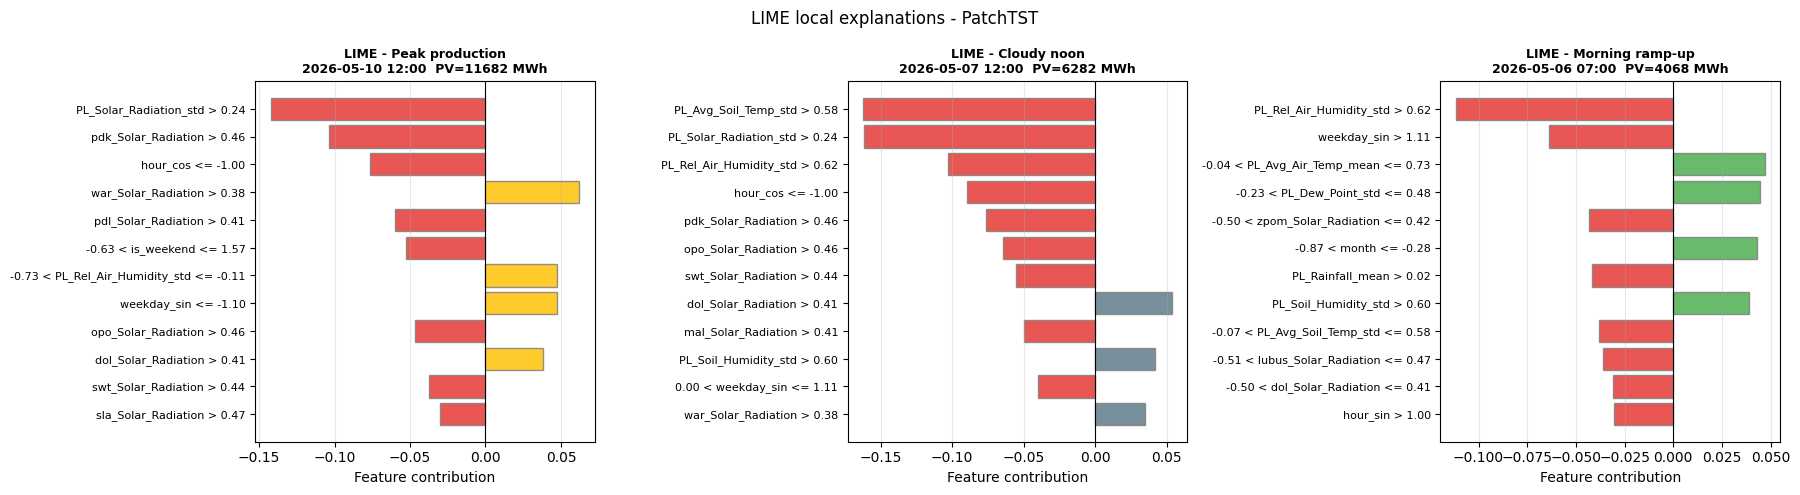

In [67]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (idx, label, color) in zip(axes, cases):
    x_current = X_val_arr[idx, interp_idx]
    exp = lime_explainer.explain_instance(
        x_current, predict_for_lime, num_features=12, num_samples=500,
    )
    feat_val_list = exp.as_list()
    feat_names_lime = [fv[0] for fv in feat_val_list]
    feat_vals_lime  = [fv[1] for fv in feat_val_list]
    bar_colors = [color if v > 0 else "#E53935" for v in feat_vals_lime]
    y_pos = list(range(len(feat_names_lime)))

    ax.barh(y_pos[::-1], feat_vals_lime, color=bar_colors, alpha=0.85, edgecolor="gray")
    ax.axvline(0, color="black", lw=0.8)
    ax.set_yticks(y_pos[::-1]); ax.set_yticklabels(feat_names_lime, fontsize=8)
    ax.set_title(
        f"LIME - {label}\n{val_df['Date'].iloc[idx].strftime('%Y-%m-%d %H:%M')}  "
        f"PV={pv_vals[idx]:.0f} MWh",
        fontsize=9, fontweight="bold")
    ax.set_xlabel("Feature contribution")
    ax.grid(alpha=0.3, axis="x")

plt.suptitle(f"LIME local explanations - {best_name}")
plt.tight_layout()
plt.show()

## 6. SHAP vs LIME - porównanie rankingu globalnego vs lokalnego

In [71]:
shap_imp_interp = (
    pd.DataFrame({
        "feature": INTERP_FEAT_NAMES,
        "shap": np.abs(shap_vals[:, :, interp_idx]).mean(axis=(0, 1))
    })
    .sort_values("shap", ascending=False)
    .reset_index(drop=True)
)

lime_agg = defaultdict(list)
for idx, _, _ in cases:
    x_current = X_val_arr[idx, interp_idx]
    exp = lime_explainer.explain_instance(
        x_current, predict_for_lime, num_features=n_interp, num_samples=300
    )
    for feat, val in exp.as_list():
        clean_name = feat.split(" ")[0]
        matched = [f for f in INTERP_FEAT_NAMES if f in feat]
        key = matched[0] if matched else clean_name
        lime_agg[key].append(abs(val))

lime_df = pd.DataFrame(
    [{"feature": k, "lime": np.mean(v)} for k, v in lime_agg.items()]
).sort_values("lime", ascending=False).reset_index(drop=True)

merged = (
    shap_imp_interp.merge(lime_df, on="feature", how="outer")
    .fillna(0)
    .sort_values("shap", ascending=False)
    .head(15)
)
merged["shap_rank"] = range(1, len(merged) + 1)
merged["lime_rank"] = merged["lime"].rank(ascending=False).astype(int)
merged

,feature,shap,lime,shap_rank,lime_rank
3,PL_Avg_Soil_Temp_std,0.054666,0.088895,1,1
35,month_cos,0.046814,0.000000,2,13
15,PL_Solar_Radiation_std,0.044784,0.087825,3,2
9,PL_Rel_Air_Humidity_std,0.036702,0.050558,4,3
1,PL_Avg_Air_Temp_std,0.027844,0.030269,5,5
20,dayofyear_cos,0.026847,0.000000,6,13
40,pom_Solar_Radiation,0.026231,0.019152,7,9
24,hour_cos,0.025021,0.000000,8,13
17,PL_Wind_Speed_std,0.024239,0.019775,9,8
30,lub_Solar_Radiation,0.019725,0.015287,10,11


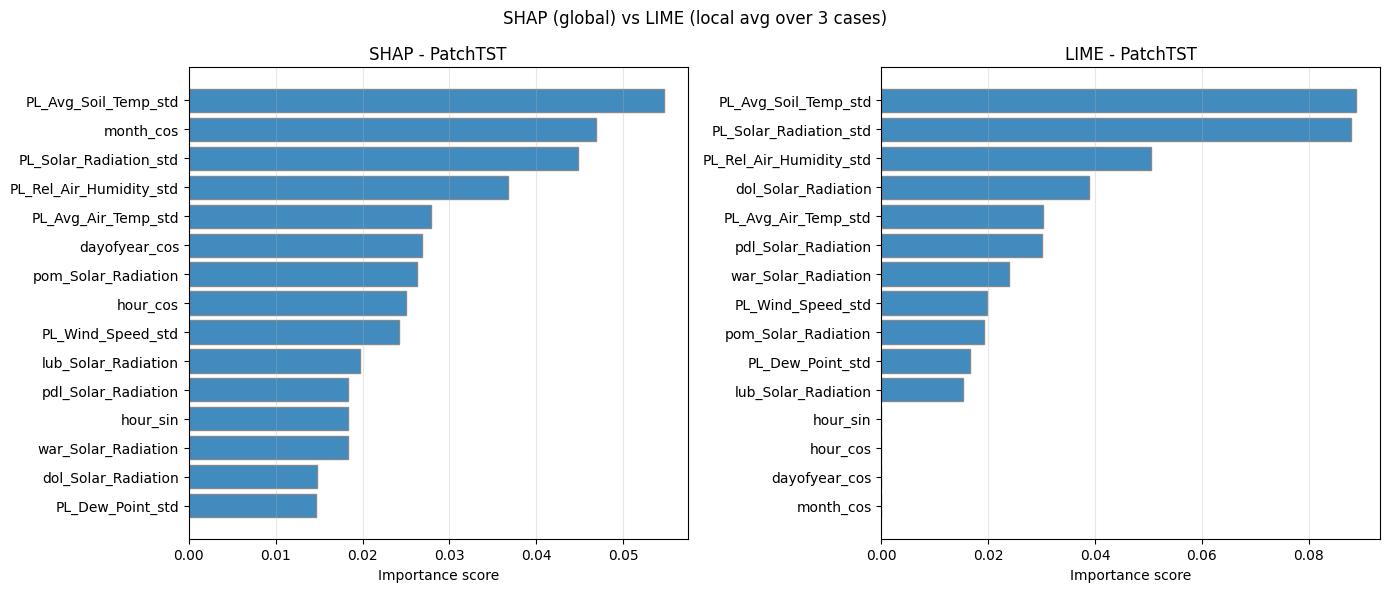

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
top15 = merged.head(15)

for ax, col, label in [
    (axes[0], "shap", f"SHAP - {best_name}"),
    (axes[1], "lime", f"LIME - {best_name}"),
]:
    df_sorted = top15.sort_values(col)
    ax.barh(df_sorted["feature"], df_sorted[col], alpha=0.85, edgecolor="gray")
    ax.set_title(label)
    ax.set_xlabel("Importance score")
    ax.grid(alpha=0.3, axis="x")

plt.suptitle("SHAP (global) vs LIME (local avg over 3 cases)")
plt.tight_layout()
plt.show()

## 7. Test na słonecznych dniach
Drugi rodzaj testu: zamiast jednego ciągłego 7-dniowego okna walidacyjnego, wybieramy słoneczne dni z 85 kwantyla.

- Zbiór treningowy (`dataset_sunny_train.csv`) to cały dataset bez wybranych słonecznych dni
- Zbiór walidacyjny (`dataset_sunny_val.csv`) 24h każdego słonecznego dnia
- Dla każdego słonecznego dnia budujemy osobną prognozę day-ahead: 48h kontekstu **przed** dniem (z danych treningowych) → 24h prognozy

In [88]:
train_sn = pd.read_csv(f"{DATA_DIR}/dataset_sunny_train.csv", parse_dates=["Date"]).sort_values("Date").reset_index(drop=True)
val_sn   = pd.read_csv(f"{DATA_DIR}/dataset_sunny_val.csv",   parse_dates=["Date"])

In [89]:
scaler_X_sn = StandardScaler()
scaler_y_sn = StandardScaler()
X_train_sn_arr = scaler_X_sn.fit_transform(train_sn[MODEL_FEATURES].values.astype("float32"))
y_train_sn_arr = scaler_y_sn.fit_transform(train_sn[[TARGET]].values.astype("float32"))
X_train_sn_seq, y_train_sn_seq = make_sequences(X_train_sn_arr, y_train_sn_arr, LOOKBACK, HORIZON)

# Sekwencje walidacyjne: dla każdego słonecznego dnia osobne okno day-ahead
#   X = 48h kontekstu PRZED dniem (z train_sn),  y = 24h docelowe (z val_sn)
day_dates_sn = sorted(val_sn["DayDate"].unique())
Xv_sn, yv_sn, persist_vals_sn, sunny_days_meta = [], [], [], []
for d in day_dates_sn:
    day_start = pd.Timestamp(d)
    ctx = train_sn[(train_sn["Date"] >= day_start - pd.Timedelta(hours=LOOKBACK)) & (train_sn["Date"] <  day_start)]
    day_rows = val_sn[val_sn["DayDate"] == d].sort_values("Date").reset_index(drop=True)
    if len(ctx) != LOOKBACK or len(day_rows) != HORIZON:
        print(f"Pomijam {d}: kontekst={len(ctx)}, target={len(day_rows)}")
        continue
    Xc = scaler_X_sn.transform(ctx[MODEL_FEATURES].values.astype("float32"))
    yc = scaler_y_sn.transform(day_rows[[TARGET]].values.astype("float32"))[:, 0]
    Xv_sn.append(Xc)
    yv_sn.append(yc)
    persist_vals_sn.append(ctx[TARGET].values[-1])   # PV o 23:00 dnia poprzedniego (baseline)
    sunny_days_meta.append((str(d), day_rows))

X_val_sn_seq = np.array(Xv_sn, dtype="float32")
y_val_sn_seq = np.array(yv_sn, dtype="float32")

In [91]:
X_nn_tr_sn, y_nn_tr_sn = X_train_sn_seq[:-ISPLIT], y_train_sn_seq[:-ISPLIT]
X_nn_vl_sn, y_nn_vl_sn = X_train_sn_seq[-ISPLIT:], y_train_sn_seq[-ISPLIT:]

loader_tr_sn  = make_loader(X_nn_tr_sn, y_nn_tr_sn, shuffle=True)
loader_vl_sn  = make_loader(X_nn_vl_sn, y_nn_vl_sn)
loader_val_sn = make_loader(X_val_sn_seq, y_val_sn_seq)

n_seq_sn = len(X_val_sn_seq)
print(f"Trening (bez słonecznych dni): {train_sn.shape[0]:,} wierszy")
print(f"X_train_sn : {X_train_sn_seq.shape} y_train_sn : {y_train_sn_seq.shape}")
print(f"X_val_sn   : {X_val_sn_seq.shape}  ({n_seq_sn} słonecznych dni × 24h)  y_val_sn : {y_val_sn_seq.shape}")

Trening (bez słonecznych dni): 10,709 wierszy
X_train_sn : (10638, 48, 177) y_train_sn : (10638, 24)
X_val_sn   : (6, 48, 177)  (6 słonecznych dni × 24h)  y_val_sn : (6, 24)


### Trening na zbiorze bez słonecznych dni

In [96]:
print(DEVICE)

mps


In [98]:
tsmixer_sn = TSMixer(
    seq_len    = LOOKBACK,
    horizon    = HORIZON,
    n_features = features_nmbr,
    n_blocks   = 2,
    expansion  = 2,
    dropout    = 0.2,
).to(DEVICE)
print(f"TSMixer trainable parameters: {sum(p.numel() for p in tsmixer_sn.parameters()):,}")

print("Training TSMixer...")
history_ts_sn = train_model(
    tsmixer_sn, loader_tr_sn, loader_vl_sn,
    epochs=MAX_EPOCHS, min_epochs=MIN_EPOCHS, lr=LR,
    weight_decay=1e-4, patience=PATIENCE, device=DEVICE,
)

TSMixer trainable parameters: 461,742
Training TSMixer...
Epoch    1 | train=0.3137  val=0.2266  lr=1.00e-03
Epoch   10 | train=0.1241  val=0.2158  lr=9.94e-04
Epoch   20 | train=0.1659  val=0.2780  lr=9.76e-04
Epoch   30 | train=0.1216  val=0.2825  lr=9.46e-04
Epoch   40 | train=0.0915  val=0.3024  lr=9.05e-04
Early stopping at epoch 49. Best val: 0.1875


In [99]:
patchtst_sn = PatchTST(
    seq_len    = LOOKBACK,
    horizon    = HORIZON,
    n_features = features_nmbr,
    patch_len  = 8,
    d_model    = 64,
    n_heads    = 4,
    n_layers   = 2,
    dropout    = 0.1,
).to(DEVICE)
print(f"PatchTST trainable parameters: {sum(p.numel() for p in patchtst_sn.parameters()):,}")

print("Training PatchTST...")
history_pt_sn = train_model(
    patchtst_sn, loader_tr_sn, loader_vl_sn,
    epochs=MAX_EPOCHS, min_epochs=MIN_EPOCHS, lr=LR,
    weight_decay=1e-4, patience=PATIENCE, device=DEVICE,
)

PatchTST trainable parameters: 200,408
Training PatchTST...
Epoch    1 | train=0.1278  val=0.1916  lr=1.00e-03
Epoch   10 | train=0.0221  val=0.2006  lr=9.94e-04
Epoch   20 | train=0.0148  val=0.2426  lr=9.76e-04
Epoch   30 | train=0.0114  val=0.2537  lr=9.46e-04
Epoch   40 | train=0.0096  val=0.2317  lr=9.05e-04
Early stopping at epoch 49. Best val: 0.1767


In [101]:
print(f"Evaluating TSMixer {n_seq_sn} sunny days (day-ahead  )...")
preds_ts_sn, trues_ts_sn, metrics_ts_sn = evaluate(tsmixer_sn, loader_val_sn, scaler_y=scaler_y_sn, device=DEVICE)
print(f"Evaluating PatchTST {n_seq_sn} sunny days (day-ahead  )...")
preds_pt_sn, trues_pt_sn, metrics_pt_sn = evaluate(patchtst_sn, loader_val_sn, scaler_y=scaler_y_sn, device=DEVICE)

Evaluating TSMixer 6 sunny days (day-ahead  )...

───────────────────────────────────
  MAE  : 835.2036
  RMSE : 1116.8713
  MAPE : 243.56%
───────────────────────────────────

Evaluating PatchTST 6 sunny days (day-ahead  )...

───────────────────────────────────
  MAE  : 580.4570
  RMSE : 838.0294
  MAPE : 103.14%
───────────────────────────────────



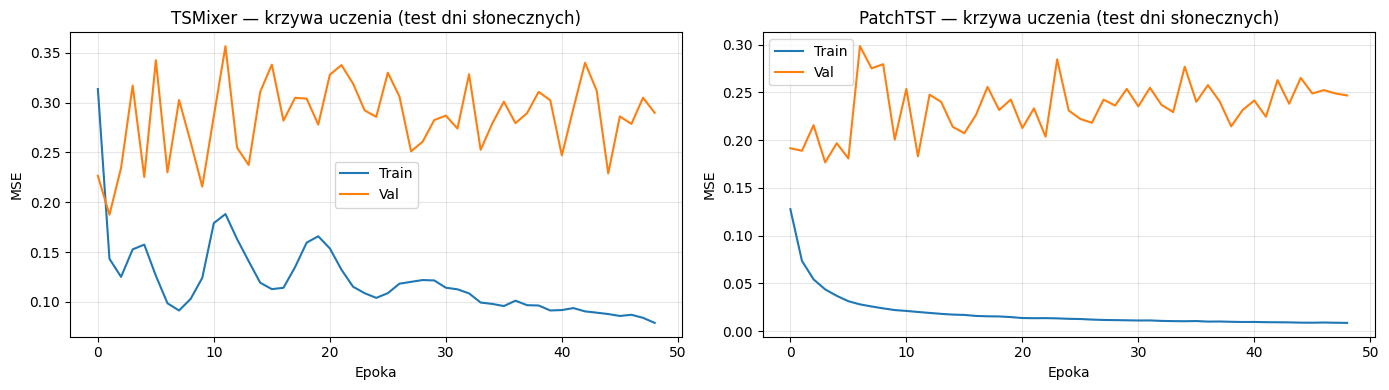

In [102]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, hist, title in [(axes[0], history_ts_sn, "TSMixer"), (axes[1], history_pt_sn, "PatchTST")]:
    ax.plot(hist["train_loss"], label="Train")
    ax.plot(hist["val_loss"],   label="Val")
    ax.set_title(f"{title} — krzywa uczenia (test dni słonecznych)")
    ax.set_xlabel("Epoka"); ax.set_ylabel("MSE")
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Krzywe uczenia mają zbliżony wykres w porównaniu do walidacji na 7 ostatnich dniach zbioru. Natomiast wartości metryk popawiły się znacząco dla tsmixera. Dla modelu PatchTST MAE i RMSE się poprawiłī, jednak MAPE się delikatnie powiększyło (teraz już przekracza 100%).

### Porównanie do baseline persistance
Powtarzamy ostatnią znaną wartość PV (23:00 dnia poprzedniego) przez 24h

In [ ]:
# Baseline persistence: powtarzamy ostatnią znaną wartość PV (23:00 dnia poprzedniego) przez 24h
persist_preds_sn = np.repeat(np.array(persist_vals_sn, dtype="float32").reshape(-1, 1), HORIZON, axis=1)
persist_mae_sn = np.mean(np.abs(trues_ts_sn.flatten() - persist_preds_sn.flatten()))

rows_sn = []
for model_name, preds_arr in [
    ('Persistence', persist_preds_sn),
    ('TSMixer',     preds_ts_sn),
    ('PatchTST',    preds_pt_sn),
]:
    rows_sn.append(compute_metrics(
        trues_ts_sn, preds_arr,
        name      = model_name,
        naive_mae = persist_mae_sn,
    ))

metrics_sn_df = pd.DataFrame(rows_sn)
metrics_sn_df

Baseline persistence MAE = 3896.2 MWh


,Model,MAE,RMSE,sMAPE (%),R2,Skill Score,MASE,MAE daytime,MAPE day (%),R2 daytime,Daily err (%)
0,Persistence,3896.199951,5675.500000,134.699997,-0.8913,0.0000,N/A,6031.600098,100.000000,-2.6960,100.0
1,TSMixer,835.200012,1116.900024,92.500000,0.9268,0.7856,N/A,993.599976,57.500000,0.8773,14.4
2,PatchTST,580.500000,838.000000,84.000000,0.9588,0.8510,N/A,776.900024,27.200001,0.9224,11.2


W porównaniu do standardowej walidacji na losowych dniach końcowych, tabela metryk dla wyselekcjonowanych dni słonecznych wskazuje na wyraźną poprawę charakterystyki pracy obu modeli. Na szczególną uwagę zasługuje drastyczna poprawa wskaźnika R^2 – zarówno w ujęciu globalnym, jak i w profilu godzinowym w ciągu dnia.

Wysoka wartość R^2, przwyższająca nawet momentami 0.9 wynika ze specyfiki dni bezchmurnych, które charakteryzują się ogromną, stabilną zmiennością dobową produkcji PV (od zera w nocy do wartości maksymalnych w południe). Model PatchTST doskonale odwzorowuje ten silny trend sinusoidalny, co matematycznie przekłada się na wysoki współczynnik R^2, mimo że bezwzględne wartości błędów (MAE) w godzinach szczytowych pozostają wysokie ze względu na dużą skalę generowanej mocy.

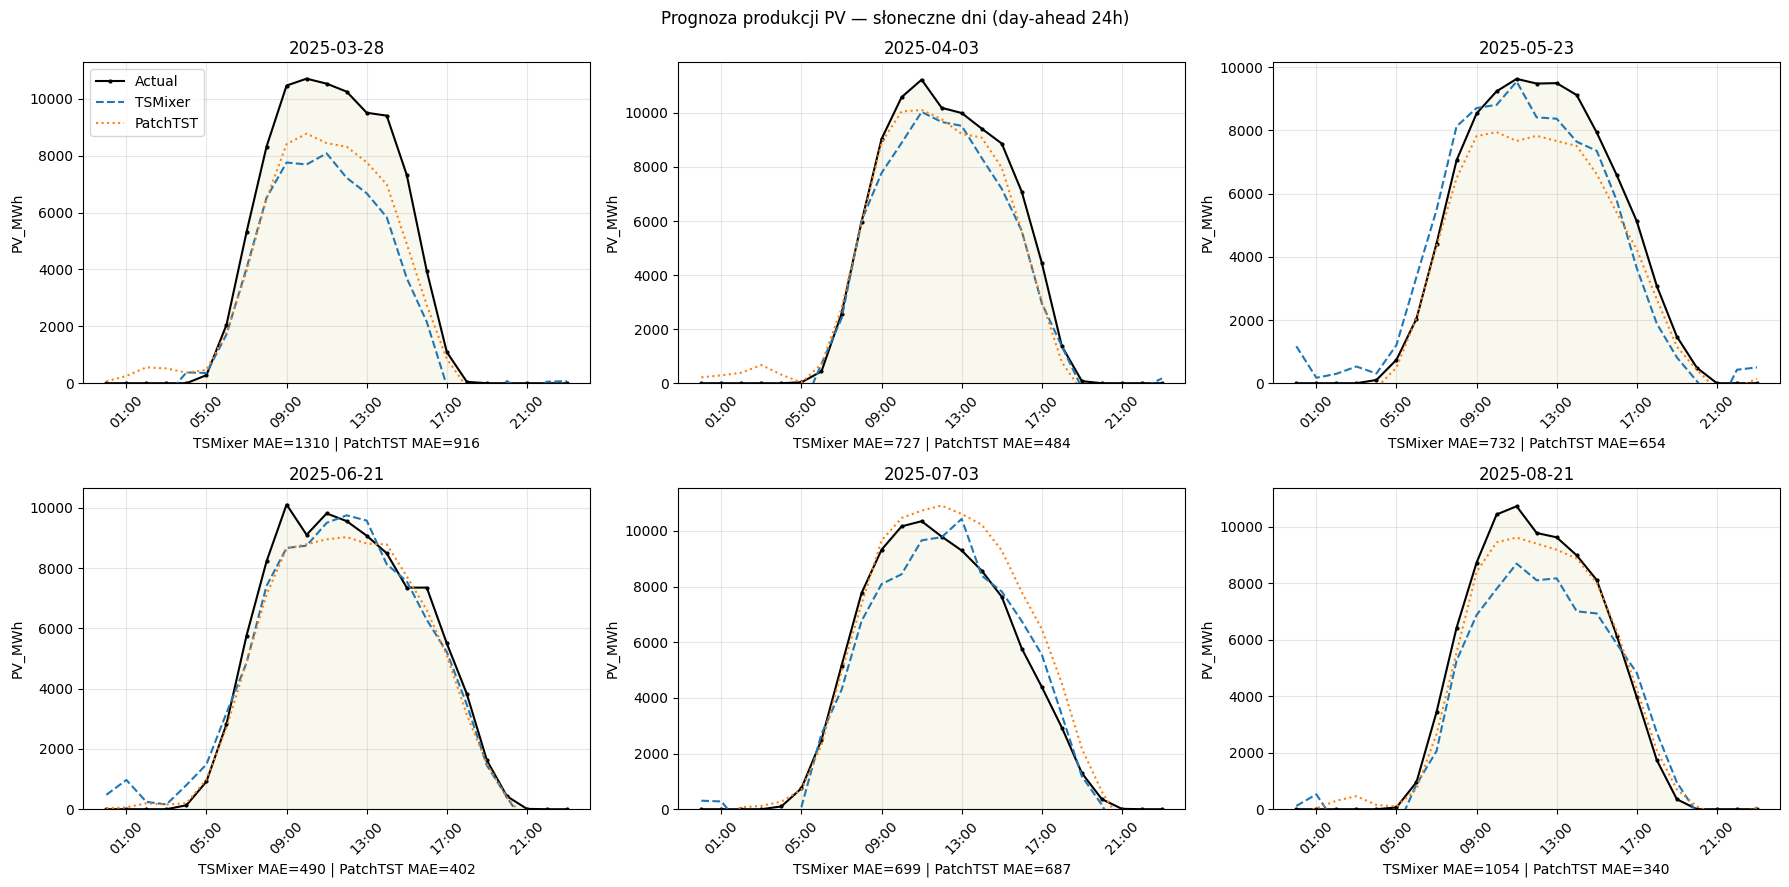

In [115]:
# Prognoza vs rzeczywistość dla każdego słonecznego dnia (siatka)
n_days = len(sunny_days_meta)
ncols  = 3
nrows  = int(np.ceil(n_days / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4.5 * nrows))
axes = np.array(axes).flatten()

for i, (d_str, day_rows) in enumerate(sunny_days_meta):
    ax     = axes[i]
    hours  = day_rows["Date"]
    y_true = trues_ts_sn[i]

    ax.fill_between(hours, 0, y_true, color="#F4F2DF", alpha=0.5)
    ax.plot(hours, y_true, "k-o", ms=2, label="Actual")
    ax.plot(hours, preds_ts_sn[i], ls="--", label="TSMixer")
    ax.plot(hours, preds_pt_sn[i], ls=":", label="PatchTST")

    ax.set_title(d_str)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=4))
    ax.tick_params(axis="x", rotation=45)
    ax.set_ylabel("PV_MWh")
    ax.set_ylim(bottom=0)
    ax.grid(alpha=0.3)

    mae_ts = np.mean(np.abs(y_true - preds_ts_sn[i]))
    mae_pt = np.mean(np.abs(y_true - preds_pt_sn[i]))
    ax.set_xlabel(f"TSMixer MAE={mae_ts:.0f} | PatchTST MAE={mae_pt:.0f}")
    if i == 0:
        ax.legend(loc="upper left")

for j in range(n_days, len(axes)):
    axes[j].axis("off")

fig.suptitle("Prognoza produkcji PV — słoneczne dni (day-ahead 24h)")
plt.tight_layout()
plt.show()

Wykresy tłumaczą dlaczego dla modelu PatchTST metryka MAPE miała pogorszoną wartość. Ten model widocznie myli się w godzinach nocnych, w których mamy praktycznie zerową produkcję pv. W porównaniu do wartości 0, łatwo by ta metryka wystrzeliła w górę.

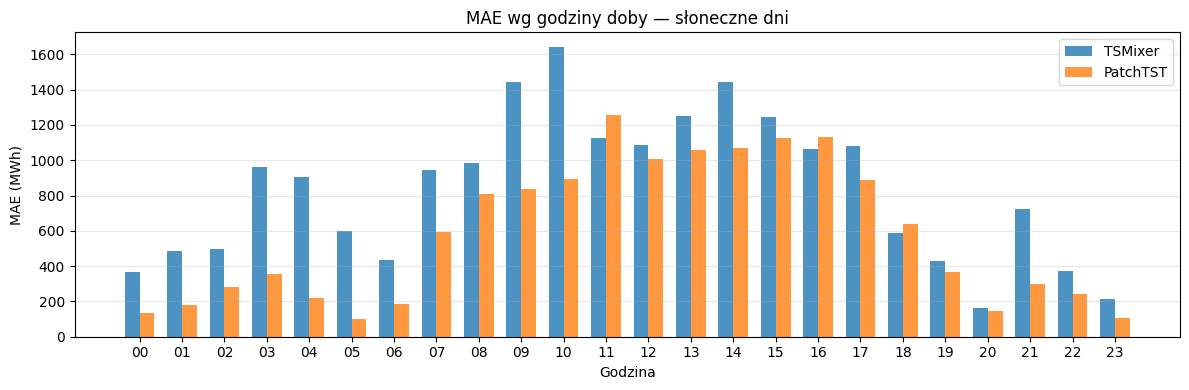

In [108]:
# MAE wg godziny doby — uśrednione po wszystkich słonecznych dniach
# (każde okno to pełny dzień 00:00–23:00, więc kolumna h = godzina h)
hours_axis  = np.arange(HORIZON)
mae_h_ts_sn = np.mean(np.abs(trues_ts_sn - preds_ts_sn), axis=0)
mae_h_pt_sn = np.mean(np.abs(trues_ts_sn - preds_pt_sn), axis=0)
w = 0.35

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(hours_axis - w/2, mae_h_ts_sn, w,    alpha=0.8, label="TSMixer")
ax.bar(hours_axis + w/2, mae_h_pt_sn, w, alpha=0.8, label="PatchTST")
ax.set_xticks(hours_axis)
ax.set_xticklabels([f"{h:02d}" for h in hours_axis])
ax.set_title("MAE wg godziny doby — słoneczne dni")
ax.set_xlabel("Godzina")
ax.set_ylabel("MAE (MWh)")
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

W przypadku walidacji na słonecznych dniach, również PatchTST wydaje się zwracać lepsze wyniki, tak samo jak w poprzednim sposobie walidacji. Architektura oparta na Transformerze (PatchTST) radzi sobie znacznie lepiej z długim horyzontem (h=24) niż TSMixer.